# Orbit and Constellation Generation Validation

The other validation notebooks model operational missions with their published two-line element (TLE) sets. For mission design, TAT-C instead generates orbits and constellations from a few parameters: a `SunSynchronousOrbit` from an altitude and an equator crossing time, a `WalkerConstellation` from its pattern, a `TrainConstellation` from a lead orbit and an interval, and `MolniyaOrbit`, `TundraOrbit`, and `GeosynchronousOrbit` designs that repeat their ground tracks. This notebook tests whether these generators reproduce operational missions designed to the same patterns:

1. **Sun-synchronous orbits.** Do generated orbits have the inclination and local time of the ascending node of 13 operational sun-synchronous missions, and keep that local time?
2. **Walker constellations.** Do Walker patterns reproduce the satellite positions of Galileo, BeiDou-3, GLONASS, and OneWeb, and the number of satellites they make visible?
3. **Train constellations.** Do trains reproduce pairs of satellites flying in the same plane (NOAA-20 and NOAA-21) or over the same ground track days apart (Sentinel-2B and 2C, Landsat 8 and 9)?
4. **Repeating highly elliptical and geosynchronous orbits.** Do Molniya orbits keep their apogees over the same longitudes, like the Meridian and EKS satellites? How do Tundra and geosynchronous designs compare with QZSS and GOES?

Each generated orbit is converted to general perturbations (SGP4) elements, as for any TAT-C analysis, and propagated alongside the operational satellites' TLEs.

## Reference Data

TLEs of operational satellites are retrieved from [CelesTrak](https://celestrak.org/) for groups of satellites (weather, Earth resources, Galileo, BeiDou, GLONASS, GPS, OneWeb, GOES) and by name (Meridian, EKS, QZSS), with epochs of 3 and 4 October 2026, and cached in a local `data/orbits` directory. Mean elements are evaluated at 12:00 UTC on 4 October 2026, by SGP4 propagation of each TLE.

In [1]:
import math
from datetime import datetime, time, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "orbits"
DATA_DIR.mkdir(parents=True, exist_ok=True)
T = datetime(2026, 10, 4, 12, tzinfo=timezone.utc)
CELESTRAK = "https://celestrak.org/NORAD/elements/gp.php"
GROUPS = ["weather", "resource", "galileo", "beidou", "glo-ops", "gps-ops", "oneweb", "goes"]
NAMES = {"meridian": ["MERIDIAN", "COSMOS 2510", "COSMOS 2518", "COSMOS 2541", "COSMOS 2552", "COSMOS 2563"], "qzss": ["QZS"]}


def fetch(path, params_list):
    if not path.exists():
        text = ""
        for params in params_list:
            response = requests.get(CELESTRAK, params={**params, "FORMAT": "tle"}, timeout=120)
            response.raise_for_status()
            text += "\n".join(line for line in response.text.splitlines() if "No GP data" not in line) + "\n"
        path.write_text(text)
    lines = [line.rstrip() for line in path.read_text().splitlines() if line.strip()]
    return {lines[i].strip(): lines[i + 1 : i + 3] for i in range(0, len(lines) - 2, 3)}


TLES = {group: fetch(DATA_DIR / f"{group}.tle", [{"GROUP": group}]) for group in GROUPS}
TLES.update({key: fetch(DATA_DIR / f"{key}.tle", [{"NAME": name} for name in names]) for key, names in NAMES.items()})
pd.Series({group: len(tles) for group, tles in TLES.items()}, name="satellites")

weather      71
resource    167
galileo      32
beidou       54
glo-ops      27
gps-ops      32
oneweb      651
goes          6
meridian     12
qzss          6
Name: satellites, dtype: int64

## Setup

Orbital elements are computed from positions and velocities propagated to the reference time: the inclination and right ascension of the ascending node from the angular momentum, and the argument of latitude (the angle from the ascending node to the satellite). The local time of the ascending node is found by propagating an orbit for a day and interpolating its northbound equator crossings: their local mean solar time is the universal time plus the crossing longitude (15 deg per hour).

In [2]:
import cartopy.crs as ccrs  # noqa: F401
import matplotlib.pyplot as plt
from skyfield.api import EarthSatellite, wgs84
from skyfield.framelib import itrs

from tatc.constants import EARTH_MEAN_RADIUS, EARTH_MU, de421, timescale
from tatc.schemas import (
    CircularOrbit,
    GeosynchronousOrbit,
    KeplerianOrbit,
    MolniyaOrbit,
    SunSynchronousOrbit,
    TrainConstellation,
    TundraOrbit,
    WalkerConstellation,
)
from tatc.schemas.space.walker import WalkerConfiguration
from tatc.utils import geodesic_distance
from tatc.utils.orbital import mean_anomaly_to_true_anomaly

t_ref = timescale.from_datetime(T)


def satellite(group, name):
    return EarthSatellite(*TLES[group][name], name, timescale)


def state_elements(track):
    """Inclination, right ascension of ascending node, argument of latitude (deg), and radius (m) of orbit track(s)."""
    r, v = track.position.m, track.velocity.m_per_s
    h = np.cross(r, v, axis=0)
    hn = np.linalg.norm(h, axis=0)
    inclination = np.degrees(np.arccos(h[2] / hn))
    raan = np.degrees(np.arctan2(h[0], -h[1])) % 360
    node = np.array([np.cos(np.radians(raan)), np.sin(np.radians(raan)), np.zeros_like(raan)])
    u = np.degrees(np.arctan2(np.sum(np.cross(node, r, axis=0) * h, axis=0) / hn, np.sum(node * r, axis=0))) % 360
    return inclination, raan, u, np.linalg.norm(r, axis=0)


def node_local_time(at, start, days=1, step=20):
    """Median local mean solar time (hours) of northbound equator crossings over a period."""
    seconds = np.arange(0, days * 86400, step)
    p = at(timescale.from_datetimes([start + timedelta(seconds=float(s)) for s in seconds])).frame_xyz(itrs).m
    k = np.nonzero((p[2][:-1] < 0) & (p[2][1:] >= 0))[0]
    f = -p[2][k] / (p[2][k + 1] - p[2][k])
    longitude = np.degrees(np.arctan2(p[1][k] + f * (p[1][k + 1] - p[1][k]), p[0][k] + f * (p[0][k + 1] - p[0][k])))
    hours = (start - start.replace(hour=0, minute=0, second=0, microsecond=0)) / timedelta(hours=1) + (seconds[k] + f * step) / 3600
    return float(np.median(np.mod(hours + longitude / 15, 24)))


def wrap(x):
    return (np.asarray(x) + 180) % 360 - 180


def summarize(x):
    x = np.abs(np.asarray(x, dtype=float))
    return pd.Series({"median |x|": np.median(x), "p90 |x|": np.percentile(x, 90), "max |x|": x.max()})


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})

## Test 1: Sun-Synchronous Orbits

For each of 13 operational sun-synchronous missions, the mean altitude is derived from its TLE's mean motion and the local time of the ascending node is measured over a day of propagation. A `SunSynchronousOrbit` with that altitude and an ascending equator crossing time equal to the measured local time is generated at the TLE's epoch, and its inclination and local time of the ascending node are compared with the mission's, at the epoch and after a year of propagation (without drag).

In [3]:
SSO_MISSIONS = [
    ("weather", "SUOMI NPP"), ("weather", "NOAA 20 (JPSS-1)"), ("weather", "NOAA 21 (JPSS-2)"), ("weather", "METOP-B"), ("weather", "METOP-C"),
    ("resource", "LANDSAT 8"), ("resource", "LANDSAT 9"), ("resource", "SENTINEL-2A"), ("resource", "SENTINEL-2B"), ("resource", "SENTINEL-2C"),
    ("resource", "SENTINEL-3A"), ("resource", "SENTINEL-3B"), ("resource", "SENTINEL-5P"),
]
rows1 = {}
for group, name in SSO_MISSIONS:
    sat = satellite(group, name)
    epoch = sat.epoch.utc_datetime()
    ltan = node_local_time(sat.at, epoch)
    altitude = (EARTH_MU / (sat.model.no_kozai / 60) ** 2) ** (1 / 3) - EARTH_MEAN_RADIUS
    hours, minutes = divmod(ltan * 60, 60)
    orbit = SunSynchronousOrbit(
        mean_altitude=altitude,
        equator_crossing_time=time(int(hours), int(minutes), int((minutes % 1) * 60)),
        equator_crossing_ascending=True,
        epoch=epoch,
    )
    generated = orbit.to_gp_orbit().elements[0].to_skyfield()
    ltan_generated = node_local_time(generated.at, epoch)
    ltan_year = node_local_time(generated.at, epoch + timedelta(days=365))
    rows1[name] = {
        "altitude (km)": altitude / 1e3,
        "inclination (deg)": math.degrees(sat.model.inclo),
        "TAT-C inclination (deg)": orbit.get_inclination(),
        "local time of ascending node (h)": ltan,
        "TAT-C minus mission (min)": 60 * wrap(15 * (ltan_generated - ltan)) / 15,
        "TAT-C drift over a year (min)": 60 * wrap(15 * (ltan_year - ltan_generated)) / 15,
    }
table1 = pd.DataFrame(rows1).T
table1.round(3)

,altitude (km),inclination (deg),TAT-C inclination (deg),local time of ascending node (h),TAT-C minus mission (min),TAT-C drift over a year (min)
SUOMI NPP,834.049,98.804,98.719,13.632,-0.016,-1.982
NOAA 20 (JPSS-1),834.075,98.785,98.719,13.522,-0.009,-1.982
NOAA 21 (JPSS-2),833.997,98.713,98.718,13.419,-0.013,-1.982
METOP-B,827.539,98.638,98.691,20.904,-0.014,-1.987
METOP-C,827.493,98.731,98.691,21.470,-0.018,-1.987
LANDSAT 8,709.656,98.220,98.199,22.205,-0.016,-2.078
LANDSAT 9,709.661,98.218,98.199,22.207,-0.019,-2.078
SENTINEL-2A,796.119,98.565,98.558,22.504,-0.014,-2.011
SENTINEL-2B,796.125,98.569,98.558,22.501,-0.014,-2.011
SENTINEL-2C,796.129,98.570,98.558,22.501,-0.006,-2.011


Earlier versions of TAT-C placed the ascending node using the apparent right ascension of the Sun (in the J2000 frame). The figure shows the resulting offset of the node's local mean solar time over a year: the equation of time (the difference between apparent and mean solar time) plus the precession of the equinoxes since 2000.

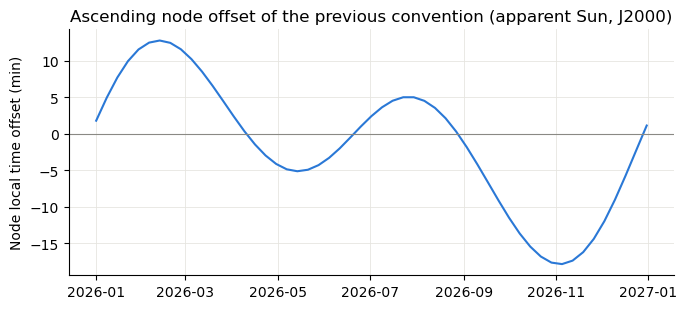

In [4]:
days = pd.date_range("2026-01-01", "2026-12-31", freq="7D", tz="UTC")
offsets = []
for day in days:
    epoch = day.to_pydatetime()
    t = timescale.from_datetime(epoch)
    ra, _, _ = de421["earth"].at(t).observe(de421["sun"]).radec()
    legacy = (ra._degrees + 360 * 13.5 / 24 + 180) % 360  # pylint: disable=protected-access
    current = SunSynchronousOrbit(mean_altitude=800e3, equator_crossing_time=time(13, 30), epoch=epoch).get_right_ascension_ascending_node()
    offsets.append(4 * wrap(legacy - current))  # 4 minutes per degree
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(days, offsets, color=BLUE)
ax.axhline(0, color=GRAY, lw=0.8)
ax.set(ylabel="Node local time offset (min)", title="Ascending node offset of the previous convention (apparent Sun, J2000)")
fig.tight_layout()
plt.show()

Generated from an altitude and an equator crossing time, every sun-synchronous orbit crosses the equator northbound within 0.02 minutes of the mission's local time. The ascending node is placed at the requested local mean solar time (universal time plus longitude), the convention used to specify missions' local times.

TAT-C's inclinations are within 0.03 deg of those of Landsat 8 and 9, Sentinel-2A, 2B, 2C, 3A, and 3B, and NOAA-21. Suomi NPP, NOAA-20, Metop-B and C, and Sentinel-5P fly inclinations 0.04 to 0.09 deg from the sun-synchronous value at their altitudes, typically to control the long-term drift of their local times under the Sun's gravity, which SGP4 does not model. The generated orbits' local times drift by 2 minutes per year under SGP4: TAT-C's inclination satisfies the sun-synchronous condition for the Earth's oblateness (J2) to within 0.001 deg, while SGP4's secular rates include higher-order terms. This drift is negligible for analyses of weeks to months.

Earlier versions of TAT-C placed the ascending node at the requested local time relative to the apparent Sun (in the J2000 frame), which offset the node's local mean solar time by the equation of time and the precession of the equinoxes since 2000: from 18 minutes early in early November to 13 minutes late in mid-February 2026 (12.7 minutes early at the epoch of these TLEs).

## Test 2: Walker Constellations

A Walker delta pattern T/P/F places T satellites in P planes equally spaced in right ascension of ascending node (over 360 deg), each with T/P satellites equally spaced along the orbit, and phases adjacent planes by F × 360/T deg; a Walker star pattern spaces the planes over 180 deg. For each constellation, the operational satellites in its nominal orbits (near-circular, at the common altitude and inclination) are compared with a `WalkerConstellation` whose lead orbit has their median altitude and inclination. The relative spacing F is chosen to minimize the satellites' offsets from the nearest slots, and the lead satellite's right ascension and argument of latitude are adjusted to the median offsets. GPS, whose six planes hold unevenly spaced satellites, is included for contrast.

In [5]:
WALKER_CASES = [
    ("galileo", "Galileo", 24, 3, WalkerConfiguration.DELTA),
    ("beidou", "BeiDou-3 (MEO)", 24, 3, WalkerConfiguration.DELTA),
    ("glo-ops", "GLONASS", 24, 3, WalkerConfiguration.DELTA),
    ("gps-ops", "GPS", 24, 6, WalkerConfiguration.DELTA),
    ("oneweb", "OneWeb", 588, 12, WalkerConfiguration.STAR),
]


def operational(group):
    """Elements of the satellites in a group's nominal orbits at the reference time."""
    rows = []
    for name in TLES[group]:
        sat = satellite(group, name)
        inclination, raan, u, radius = state_elements(sat.at(t_ref))
        rows.append({"name": name, "inclination": inclination, "raan": raan, "u": u, "radius": radius, "eccentricity": sat.model.ecco, "n": sat.model.no_kozai})
    frame = pd.DataFrame(rows)
    nominal = (frame.eccentricity < 0.02) & ((frame.n / frame.n.median() - 1).abs() < 0.003) & ((frame.inclination - frame.inclination.median()).abs() < 5)
    return frame[nominal].reset_index(drop=True)


def fit_walker(frame, total, planes, configuration):
    """Fit a Walker constellation to operational satellites; returns the constellation, slot offsets, and slot assignments."""
    best = None
    for spacing in range(planes):
        offset_u, offset_raan = 0.0, 0.0
        for _ in range(4):
            lead = CircularOrbit(
                mean_altitude=float(frame.radius.median()) - EARTH_MEAN_RADIUS,
                inclination=float(frame.inclination.median()),
                right_ascension_ascending_node=float(frame.raan[0] + offset_raan) % 360,
                true_anomaly=float(frame.u[0] + offset_u) % 360,
                epoch=T,
            )
            walker = WalkerConstellation(name="walker", orbit=lead, number_satellites=total, number_planes=planes, relative_spacing=spacing, configuration=configuration)
            members = walker.generate_members()
            slot_raan = np.array([m.orbit.get_right_ascension_ascending_node() for m in members])
            slot_u = np.array([m.orbit.true_anomaly for m in members])
            d_raan = wrap(frame.raan.to_numpy()[:, None] - slot_raan[None, :])
            d_u = wrap(frame.u.to_numpy()[:, None] - slot_u[None, :])
            slot = np.argmin(np.hypot(d_raan * np.sin(np.radians(frame.inclination.median())), d_u), axis=1)
            du, draan = d_u[np.arange(len(slot)), slot], d_raan[np.arange(len(slot)), slot]
            offset_u += float(np.median(du))
            offset_raan += float(np.median(draan))
        if best is None or np.median(np.abs(du)) < best[0]:
            best = (np.median(np.abs(du)), walker, du, draan, slot)
    return best[1:]


fits, rows2 = {}, {}
for group, label, total, planes, configuration in WALKER_CASES:
    frame = operational(group)
    walker, du, draan, slot = fit_walker(frame, total, planes, configuration)
    fits[label] = (frame, walker, du, draan, slot)
    spacing_u = 360 / walker.get_satellites_per_plane()
    rows2[label] = {
        "satellites": len(frame),
        "pattern (T/P/F)": f"{total}/{planes}/{walker.relative_spacing} {configuration.value}",
        "altitude (km)": (frame.radius.median() - EARTH_MEAN_RADIUS) / 1e3,
        "inclination (deg)": frame.inclination.median(),
        "slots occupied": f"{len(set(slot))} of {total}",
        "along-track offset, median (deg)": np.median(np.abs(du)),
        "along-track offset, p90 (deg)": np.percentile(np.abs(du), 90),
        "slot spacing (deg)": spacing_u,
        "plane offset, median (deg)": np.median(np.abs(draan)),
    }
pd.DataFrame(rows2).T

,satellites,pattern (T/P/F),altitude (km),inclination (deg),slots occupied,"along-track offset, median (deg)","along-track offset, p90 (deg)",slot spacing (deg),"plane offset, median (deg)"
Galileo,30,24/3/1 delta,23229.686596,55.694843,24 of 24,1.04411,21.438864,45.0,0.317814
BeiDou-3 (MEO),33,24/3/1 delta,21535.263048,54.42014,24 of 24,2.56048,20.22642,45.0,0.684403
GLONASS,27,24/3/1 delta,19140.122388,65.036153,24 of 24,2.11311,6.479661,45.0,0.901057
GPS,31,24/6/1 delta,20169.357442,54.864918,21 of 24,16.555272,38.129103,90.0,2.130069
OneWeb,374,588/12/2 star,1210.077019,87.803158,326 of 588,1.736397,3.252636,7.346939,0.575148


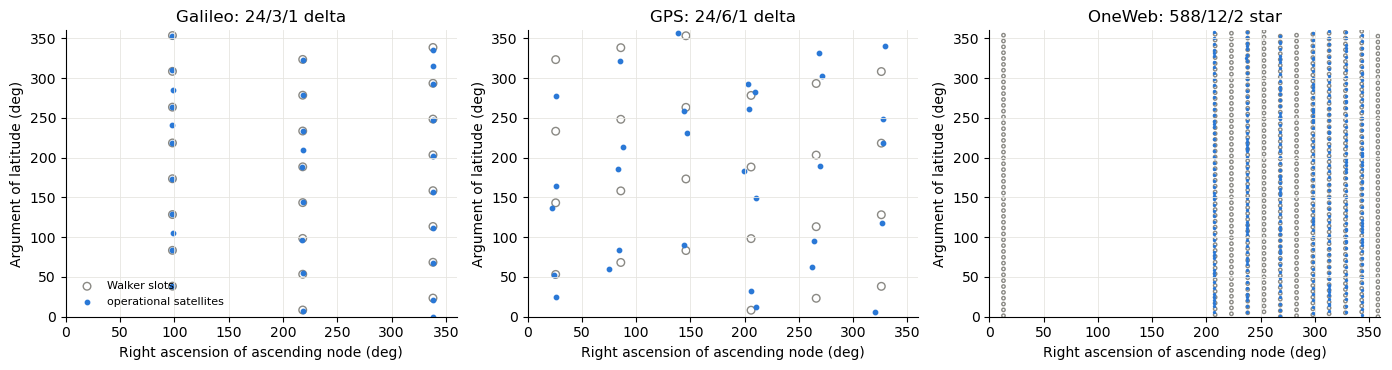

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, label in zip(axes, ["Galileo", "GPS", "OneWeb"]):
    frame, walker, _, _, _ = fits[label]
    members = walker.generate_members()
    ax.scatter([m.orbit.get_right_ascension_ascending_node() for m in members], [m.orbit.true_anomaly for m in members], s=30 if label != "OneWeb" else 6, facecolors="none", edgecolors=GRAY, label="Walker slots")
    ax.scatter(frame.raan, frame.u, s=10 if label != "OneWeb" else 2, color=BLUE, label="operational satellites")
    ax.set(xlabel="Right ascension of ascending node (deg)", ylabel="Argument of latitude (deg)", title=f"{label}: {rows2[label]['pattern (T/P/F)']}", xlim=(0, 360), ylim=(0, 360))
axes[0].legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

The constellations are also compared by what they provide: the number of satellites above 10 deg elevation from points at latitudes 0 to 80 deg (at 0 deg longitude), averaged over a day (every 10 minutes) for the navigation constellations and over two hours (every 2 minutes) for OneWeb. For a like-for-like comparison, each occupied Walker slot is compared with the operational satellite closest to it (spares and empty slots are excluded).

In [7]:
LATITUDES = np.arange(0, 81, 10)


def mean_visible(tracks, times, min_elevation=10):
    """Mean number of satellites above an elevation angle at each latitude."""
    position = np.stack([track.frame_xyz(itrs).m for track in tracks], axis=1)  # (3, satellites, times)
    counts = []
    for latitude in LATITUDES:
        site = wgs84.latlon(latitude, 0)
        p = np.array(site.itrs_xyz.m)[:, None, None]
        up = np.array([np.cos(np.radians(latitude)), 0, np.sin(np.radians(latitude))])[:, None, None]
        line = position - p
        elevation = np.degrees(np.arcsin(np.sum(line * up, axis=0) / np.linalg.norm(line, axis=0)))
        counts.append(np.mean(np.sum(elevation >= min_elevation, axis=0)))
    return np.array(counts)


visible = {}
for group, label, total, planes, configuration in WALKER_CASES:
    frame, walker, _, _, slot = fits[label]
    members = walker.generate_members()
    # the operational satellite closest to each occupied slot
    cost = np.abs(fits[label][2])
    closest = pd.Series(cost).groupby(slot).idxmin()
    duration, step = (timedelta(days=1), timedelta(minutes=10)) if label != "OneWeb" else (timedelta(hours=2), timedelta(minutes=2))
    times = timescale.from_datetimes([T + k * step for k in range(int(duration / step))])
    real_tracks = [satellite(group, frame.name[i]).at(times) for i in closest.to_numpy()]
    walker_tracks = [members[k].orbit.to_gp_orbit().elements[0].to_skyfield().at(times) for k in closest.index]
    visible[label] = (mean_visible(real_tracks, times), mean_visible(walker_tracks, times))
pd.DataFrame(
    {(label, kind): counts for label, (real_counts, walker_counts) in visible.items() for kind, counts in [("operational", real_counts), ("Walker", walker_counts)]},
    index=pd.Index(LATITUDES, name="latitude (deg)"),
).round(1)

Galileo        BeiDou-3 (MEO)            GLONASS         \
               operational Walker    operational Walker operational Walker   
latitude (deg)                                                               
0                      7.8    7.8            7.9    7.9         6.9    6.9   
10                     7.7    7.8            7.8    7.7         6.7    6.7   
20                     7.2    7.1            7.2    7.2         6.7    6.7   
30                     7.1    7.0            6.9    7.0         6.7    6.7   
40                     7.0    7.0            6.8    6.8         6.9    6.9   
50                     7.1    7.1            6.9    6.8         7.5    7.5   
60                     7.8    7.8            7.6    7.5         8.0    8.0   
70                     8.2    8.2            8.0    7.9         8.3    8.2   
80                     8.3    8.3            8.1    8.1         8.4    8.4   

                       GPS             OneWeb         
               operational Walker operational Walker  
latitude (deg)                                        
0                      6.7    6.8         7.2    7.2  
10                     6.5    6.6         7.3    7.1  
20                     6.1    6.1         7.5    7.4  
30                     5.9    5.9         7.9    7.7  
40                     5.8    5.8         8.6    8.3  
50                     5.8    5.9        10.2    9.9  
60                     6.4    6.4        13.8   13.4  
70                     6.9    6.8        30.2   30.0  
80                     7.0    7.0        40.3   40.5

Galileo, BeiDou-3, and GLONASS are all Walker 24/3/1 constellations: every slot is occupied, the median satellite lies within 1 to 3 deg of its slot along the orbit (of 45 deg between slots), and the planes lie within 1 deg of the pattern's. The satellites far from any slot (the 90th percentile offsets of about 20 deg) are spares parked between slots: Galileo and BeiDou have 6 and 9 more satellites in their nominal orbits than slots. OneWeb is a Walker star constellation of 12 planes spaced over 180 deg: the 374 satellites in its nominal orbit (at 1,210 km) occupy 326 of 588 slots, within 1.7 deg (median) of them along the orbit (of 7.3 deg between slots). With 49 satellites per plane, the relative spacing F (2, here) shifts slots by less than a degree and is poorly determined. GPS is not a Walker constellation: its satellites lie 17 deg (median) from the slots of the closest 24/6/F pattern, of 90 deg between slots.

For the satellites in slots, the Walker constellations provide the same number of visible satellites as the operational constellations, within 0.1 (navigation constellations) and 0.4 (OneWeb) at every latitude. Even GPS agrees, because a daily average of visible satellites is insensitive to how they are phased; the dilution of precision, which depends on the instantaneous geometry, is tested in the [GNSS DOP](ValidateDopGNSS.ipynb) notebook.

## Test 3: Train Constellations

A `TrainConstellation` places each member satellite one interval behind the one ahead of it along the lead orbit; with `repeat_ground_track`, each member also follows the ground track of the one ahead of it. Three operational pairs are compared with the second member of a train whose lead orbit is the first satellite's (a circular orbit with its altitude, inclination, right ascension of ascending node, and argument of latitude at the reference time):

* **NOAA-20 and NOAA-21** fly in nearly the same plane, NOAA-21 about half an orbit behind: a train without a repeating ground track, with an interval of NOAA-21's measured phase lag;
* **Sentinel-2B and 2C** and **Landsat 8 and 9** fly in the same plane, half an orbit apart, so that the second satellite follows the first's ground track 5 days (half of Sentinel-2's 10 day repeat cycle) or 8 days (half of Landsat's 16 day repeat cycle) later: trains with a repeating ground track.

For comparison, the second member's elements are also computed with the train formulas of earlier versions of TAT-C, which shifted the right ascension of ascending node by the Earth's rotation during the interval and the mean anomaly by the two-body mean motion.

In [8]:
TRAIN_CASES = [
    ("weather", "NOAA 20 (JPSS-1)", "NOAA 21 (JPSS-2)", None, False),
    ("resource", "SENTINEL-2B", "SENTINEL-2C", timedelta(days=5), True),
    ("resource", "LANDSAT 8", "LANDSAT 9", timedelta(days=8), True),
]
SIDEREAL_DAY = 86164.0905
day_times = timescale.from_datetimes([T + timedelta(minutes=k) for k in range(0, 1440, 5)])
rows3 = {}
for group, lead_name, follow_name, interval, repeat in TRAIN_CASES:
    lead_sat, follow_sat = satellite(group, lead_name), satellite(group, follow_name)
    inclination, raan, u, _ = state_elements(lead_sat.at(t_ref))
    _, raan_follow, u_follow, _ = state_elements(follow_sat.at(t_ref))
    semimajor_axis = (EARTH_MU / (lead_sat.model.no_kozai / 60) ** 2) ** (1 / 3)
    lead = KeplerianOrbit(semimajor_axis=semimajor_axis, eccentricity=0, inclination=float(inclination), right_ascension_ascending_node=float(raan), perigee_argument=0, true_anomaly=float(u), epoch=T)
    if interval is None:
        interval = lead.get_orbit_period() * (float(wrap(u - u_follow)) % 360 / 360)
    train = TrainConstellation(name="train", orbit=lead, number_satellites=2, interval=interval, repeat_ground_track=repeat)
    member = train.generate_members()[1].orbit
    legacy = lead.get_derived_orbit(-360 * interval / lead.get_orbit_period(), 360 * interval.total_seconds() / SIDEREAL_DAY if repeat else 0)
    real_points = wgs84.subpoint_of(follow_sat.at(day_times))
    for version, orbit in [("TAT-C", member), ("previous", legacy)]:
        generated_points = wgs84.subpoint_of(orbit.to_gp_orbit().elements[0].to_skyfield().at(day_times))
        distance = np.array([geodesic_distance(*a) for a in zip(real_points.longitude.degrees, real_points.latitude.degrees, generated_points.longitude.degrees, generated_points.latitude.degrees)]) / 1e3
        rows3[(f"{lead_name} → {follow_name}", version)] = {
            "interval": str(interval).split(".")[0],
            "repeat ground track": repeat,
            "right ascension difference (deg)": float(wrap(orbit.get_right_ascension_ascending_node() - raan_follow)),
            "argument of latitude difference (deg)": float(wrap(orbit.true_anomaly - u_follow)),
            "position difference, median (km)": np.median(distance),
            "position difference, max (km)": distance.max(),
        }
pd.DataFrame(rows3).T.round(2)

interval  \
NOAA 20 (JPSS-1) → NOAA 21 (JPSS-2) TAT-C             0:44:43   
                                    previous          0:44:43   
SENTINEL-2B → SENTINEL-2C           TAT-C     5 days, 0:00:00   
                                    previous  5 days, 0:00:00   
LANDSAT 8 → LANDSAT 9               TAT-C     8 days, 0:00:00   
                                    previous  8 days, 0:00:00   

                                             repeat ground track  \
NOAA 20 (JPSS-1) → NOAA 21 (JPSS-2) TAT-C                  False   
                                    previous               False   
SENTINEL-2B → SENTINEL-2C           TAT-C                   True   
                                    previous                True   
LANDSAT 8 → LANDSAT 9               TAT-C                   True   
                                    previous                True   

                                             right ascension difference (deg)  \
NOAA 20 (JPSS-1) → NOAA 21 (JPSS-2) TAT-C                            1.548305   
                                    previous                         1.548305   
SENTINEL-2B → SENTINEL-2C           TAT-C                            0.010042   
                                    previous                         4.922065   
LANDSAT 8 → LANDSAT 9               TAT-C                            0.006071   
                                    previous                         7.867476   

                                             argument of latitude difference (deg)  \
NOAA 20 (JPSS-1) → NOAA 21 (JPSS-2) TAT-C                                 0.089425   
                                    previous                                  -0.0   
SENTINEL-2B → SENTINEL-2C           TAT-C                                -0.070377   
                                    previous                            -14.801718   
LANDSAT 8 → LANDSAT 9               TAT-C                                 0.392714   
                                    previous                            -24.445986   

                                             position difference, median (km)  \
NOAA 20 (JPSS-1) → NOAA 21 (JPSS-2) TAT-C                           95.915027   
                                    previous                        97.423519   
SENTINEL-2B → SENTINEL-2C           TAT-C                           28.970072   
                                    previous                      1762.941536   
LANDSAT 8 → LANDSAT 9               TAT-C                           45.367783   
                                    previous                      2904.691372   

                                             position difference, max (km)  
NOAA 20 (JPSS-1) → NOAA 21 (JPSS-2) TAT-C                       135.327895  
                                    previous                    136.975791  
SENTINEL-2B → SENTINEL-2C           TAT-C                        40.091848  
                                    previous                   1801.117156  
LANDSAT 8 → LANDSAT 9               TAT-C                         55.11049  
                                    previous                   2970.278553

With the lead orbit's propagated rates, the generated followers fly where the operational ones do. Sentinel-2C and Landsat 9 are reproduced within 29 and 45 km (median), in their leads' planes (within 0.01 deg) and phase (within 0.4 deg), five and eight days behind on the same ground tracks. NOAA-21 is reproduced in phase (within 0.1 deg), but TAT-C places it in NOAA-20's plane, while NOAA-21's plane is 1.5 deg to the west (its ascending node is 6 minutes earlier in local time), which separates their positions by about 96 km across track; a train with a `SunSynchronousOrbit` lead could represent the two planes only by separate orbits.

The formulas of earlier versions of TAT-C placed Sentinel-2C 1,760 km and Landsat 9 2,900 km from their actual positions. They omitted the precession of the orbit plane during the interval (about 1 deg per day for a sun-synchronous orbit), rotating the follower's plane by 4.9 and 7.9 deg, and advanced it along the orbit at the two-body mean motion rather than the propagated rate (including the Earth's oblateness), shifting it by 15 and 24 deg. Both errors grow with the interval and are negligible for trains spaced by minutes.

## Test 4: Repeating Highly Elliptical and Geosynchronous Orbits

**Molniya orbits.** A `MolniyaOrbit` has the critical inclination (63.4 deg, at which the perigee does not drift), a perigee on the southern side (argument of perigee 270 deg, for northern coverage), and a period for which the ground track repeats twice a day, so that its two daily apogees stay over the same longitudes. For each of the Meridian and EKS satellites in Molniya orbits (argument of perigee within 6 deg of 270 deg), a `MolniyaOrbit` is generated with its perigee altitude, right ascension of ascending node, and true anomaly at the reference time, and the longitudes of the two daily apogees are tracked over 30 days.

**Tundra orbits.** A `TundraOrbit` differs only in its period (one revolution per day). No operational satellite flies a Tundra orbit at the critical inclination, but the Japanese Quasi-Zenith Satellite System (QZSS) uses similar quasi-zenith orbits (one revolution per day, eccentricity 0.075, argument of perigee 270 deg) at an inclination of about 40 deg; they are compared with `TundraOrbit`s of the same perigee altitude.

In [9]:
def apogee_drift(at, revolutions, days=30):
    """Apogee longitudes and their drift rate (deg/day, mean over each daily apogee)."""
    times = timescale.from_datetimes([T + timedelta(minutes=k) for k in range(0, days * 1440, 2)])
    track = at(times)
    radius = np.linalg.norm(track.position.m, axis=0)
    k = np.nonzero((radius[1:-1] > radius[:-2]) & (radius[1:-1] >= radius[2:]))[0] + 1
    points = wgs84.subpoint_of(track[k])
    elapsed = times.tt[k] - t_ref.tt
    rates = [np.polyfit(elapsed[i::revolutions], np.degrees(np.unwrap(np.radians(points.longitude.degrees[i::revolutions]))), 1)[0] for i in range(revolutions)]
    return float(np.mean(rates)), float(np.median(points.latitude.degrees))


rows4 = {}
for group, cls, revolutions in [("meridian", MolniyaOrbit, 2), ("qzss", TundraOrbit, 1)]:
    for name in TLES[group]:
        sat = satellite(group, name)
        m = sat.model
        if m.ecco < 0.05 or abs(math.degrees(m.argpo) - 270) > 6:
            continue
        minutes = (t_ref.tt - sat.epoch.tt) * 1440
        semimajor_axis = (EARTH_MU / (m.no_kozai / 60) ** 2) ** (1 / 3)
        mean_anomaly = math.degrees(m.mo + m.mdot * minutes) % 360
        orbit = cls(
            perigee_altitude=semimajor_axis * (1 - m.ecco) - EARTH_MEAN_RADIUS,
            right_ascension_ascending_node=math.degrees(m.nodeo + m.nodedot * minutes) % 360,
            true_anomaly=float(mean_anomaly_to_true_anomaly(mean_anomaly, m.ecco)),
            epoch=T,
        )
        real_drift, real_latitude = apogee_drift(sat.at, revolutions)
        tatc_drift, tatc_latitude = apogee_drift(orbit.to_gp_orbit().elements[0].to_skyfield().at, revolutions)
        rows4[name] = {
            "TAT-C orbit": cls.__name__,
            "semimajor axis (km)": semimajor_axis / 1e3,
            "TAT-C semimajor axis (km)": orbit.get_semimajor_axis() / 1e3,
            "inclination (deg)": math.degrees(m.inclo),
            "argument of perigee (deg)": math.degrees(m.argpo),
            "apogee latitude (deg)": real_latitude,
            "TAT-C apogee latitude (deg)": tatc_latitude,
            "apogee longitude drift (deg/day)": real_drift,
            "TAT-C apogee longitude drift (deg/day)": tatc_drift,
        }
pd.DataFrame(rows4).T.round(3)

,TAT-C orbit,semimajor axis (km),TAT-C semimajor axis (km),inclination (deg),argument of perigee (deg),apogee latitude (deg),TAT-C apogee latitude (deg),apogee longitude drift (deg/day),TAT-C apogee longitude drift (deg/day)
MERIDIAN 7,MolniyaOrbit,26556.529264,26557.081606,63.4464,269.8069,63.484072,63.473707,0.004978,0.008725
MERIDIAN 8,MolniyaOrbit,26555.721771,26555.721436,63.2295,275.1028,62.8119,63.468725,0.00842,0.044798
MERIDIAN 10,MolniyaOrbit,26557.901438,26556.589065,62.6831,272.8176,62.554682,63.43918,-0.020113,-0.010681
COSMOS 2510 (EKS 1),MolniyaOrbit,26555.398968,26555.408146,63.4367,274.9529,63.033454,63.442838,-0.071961,-0.067353
COSMOS 2518 (EKS 2),MolniyaOrbit,26544.580575,26556.314167,63.0158,273.9442,62.774535,63.461396,0.253784,0.03446
COSMOS 2541 (EKS 3),MolniyaOrbit,26559.178361,26557.290352,62.7121,272.0507,62.655975,63.448162,-0.040371,0.01148
COSMOS 2552 (EKS 5),MolniyaOrbit,26559.246511,26557.508924,62.8218,272.3607,62.771854,63.474572,-0.0554,-0.046137
COSMOS 2563 (EKS 6),MolniyaOrbit,26558.730105,26556.094514,63.1495,270.006,63.153577,63.439182,-0.112041,-0.067069
QZS-2 (MICHIBIKI-2),TundraOrbit,42169.246821,42163.697249,39.2714,270.7063,39.289704,63.468099,-0.078725,-0.0116
QZS-4 (MICHIBIKI-4),TundraOrbit,42165.783816,42163.6972,40.0356,270.1211,40.049337,63.449764,-0.035572,-0.026174


**Geosynchronous orbits.** A `GeosynchronousOrbit` places a satellite over a longitude with a period of one sidereal day. Without station keeping, real geosynchronous satellites drift: the Earth's equator is slightly elliptical, which accelerates them toward stable longitudes near 75 deg east and 105 deg west. GOES-18 and GOES-19, which are kept within about 0.1 deg of their slots, are compared with `GeosynchronousOrbit`s at their longitudes, and two more longitudes are tested, over 30 days.

In [10]:
rows5 = {}
times30 = timescale.from_datetimes([T + timedelta(hours=k) for k in range(0, 30 * 24 + 1, 6)])
for label, longitude, name in [("GOES 19", None, "GOES 19"), ("GOES 18", None, "GOES 18"), ("0 deg", 0.0, None), ("105 deg E", 105.0, None)]:
    if name is not None:
        sat = satellite("goes", name)
        real = np.degrees(np.unwrap(np.radians(wgs84.subpoint_of(sat.at(times30)).longitude.degrees)))
        longitude = float(real[0])
    orbit = GeosynchronousOrbit(longitude=longitude, epoch=T)
    generated = np.degrees(np.unwrap(np.radians(wgs84.subpoint_of(orbit.to_gp_orbit().elements[0].to_skyfield().at(times30)).longitude.degrees)))
    rows5[label] = {
        "longitude (deg)": longitude,
        "TAT-C longitude at epoch (deg)": generated[0],
        "operational longitude range over 30 days (deg)": np.ptp(real) if name is not None else np.nan,
        "TAT-C longitude change over 30 days (deg)": generated[-1] - generated[0],
    }
pd.DataFrame(rows5).T.round(3)

,longitude (deg),TAT-C longitude at epoch (deg),operational longitude range over 30 days (deg),TAT-C longitude change over 30 days (deg)
GOES 19,-75.197,-75.210,0.695,-0.295
GOES 18,-136.996,-137.008,0.465,0.821
0 deg,0.000,-0.013,NaN,0.502
105 deg E,105.000,104.987,NaN,-0.564


**Molniya orbits.** The generated Molniya orbits have the semimajor axes of the Meridian and EKS satellites (within 3 km) and apogees at their latitudes (63.4 deg, versus 62.6 to 63.5 deg for operational inclinations of 62.7 to 63.4 deg). Their apogee longitudes drift by -0.07 to +0.05 deg per day, comparable to the operational satellites (-0.11 to +0.25 deg per day). This remaining drift, which differs between satellites at different longitudes, comes from SGP4's treatment of the 12-hour resonance with the Earth's gravity field and of the Moon's and Sun's gravity. Earlier versions of TAT-C did not account for the precession of the ascending node in the orbit period, so all apogees drifted westward by about 0.1 deg per day.

**Tundra orbits.** The generated Tundra orbits have the period of QZSS's quasi-zenith orbits (semimajor axes within 6 km) and drift by at most 0.03 deg per day. `TundraOrbit` fixes the inclination at the critical inclination, however, so its apogees are at 63.5 deg latitude rather than QZSS's 38 to 40 deg: a quasi-zenith orbit at a lower inclination (whose perigee drifts and must be maintained) cannot be specified as a `TundraOrbit`.

**Geosynchronous orbits.** The generated orbits start within 0.013 deg of the requested longitudes and, without station keeping, drift by -0.6 to +0.8 deg over 30 days, toward the stable longitudes (westward at 75 deg west and 105 deg east, eastward at 137 deg west and 0 deg). The operational GOES satellites, whose position is maintained, stay within 0.5 to 0.7 deg (including their daily oscillation).

## Summary

| Test | Result |
| --- | --- |
| 1. `SunSynchronousOrbit` | ascending node within 0.02 minutes of 13 missions' local times; inclination within 0.03 deg (or 0.04 to 0.09 deg for missions with biased inclinations); local time drift 2 minutes per year |
| 2. `WalkerConstellation` | Galileo, BeiDou-3, and GLONASS are Walker 24/3/1 delta and OneWeb a 12-plane Walker star: satellites in slots within 1 to 3 deg; same visible satellites within 0.4 at all latitudes; GPS is not a Walker pattern |
| 3. `TrainConstellation` | Sentinel-2C and Landsat 9 (5 and 8 days behind on the same ground track) within 29 and 45 km; NOAA-21 in phase, but 1.5 deg out of the lead's plane in reality |
| 4. `MolniyaOrbit`, `TundraOrbit`, `GeosynchronousOrbit` | Molniya apogee longitudes drift by less than 0.07 deg per day, like the operational satellites; Tundra cannot represent QZSS's 40 deg inclination; geosynchronous orbits drift by up to 0.8 deg per month without station keeping |

**Changes to TAT-C.** This validation found three errors in the orbit generators, which have been fixed:

* `SunSynchronousOrbit` placed the ascending node relative to the apparent Sun, offsetting its local mean solar time by up to 18 minutes over a year; it now uses the Greenwich mean sidereal time.
* `TrainConstellation` ignored the precession of the orbit plane and the Earth's oblateness during the interval, misplacing satellites trailing by days by thousands of kilometers; it now uses the lead orbit's propagated (SGP4) rates.
* `MolniyaOrbit` and `TundraOrbit` periods ignored the precession of the ascending node, so Molniya apogees drifted westward by 0.1 deg per day; the periods are now refined with SGP4's rates.

**Remaining limitations.** Generated orbits are not maintained: sun-synchronous local times drift by about 2 minutes per year, Molniya apogees by a few hundredths of a degree per day, and geosynchronous longitudes by up to a degree per month, as propagated by SGP4 without station keeping. `TundraOrbit` (and `MolniyaOrbit`) cannot specify inclinations other than the critical inclination.